In [ ]:
from google.colab import files
uploaded=files.upload()

Saving Iris.csv to Iris.csv


First step was to upload the downloaded Iris dataset using the upload() function.

In [ ]:
import pandas as pd
df= pd.read_csv("Iris.csv")

Then i used pandas to read the csv file.

In [ ]:
print(df)

      Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
0      1            5.1           3.5            1.4           0.2   
1      2            4.9           3.0            1.4           0.2   
2      3            4.7           3.2            1.3           0.2   
3      4            4.6           3.1            1.5           0.2   
4      5            5.0           3.6            1.4           0.2   
..   ...            ...           ...            ...           ...   
145  146            6.7           3.0            5.2           2.3   
146  147            6.3           2.5            5.0           1.9   
147  148            6.5           3.0            5.2           2.0   
148  149            6.2           3.4            5.4           2.3   
149  150            5.9           3.0            5.1           1.8   

            Species  
0       Iris-setosa  
1       Iris-setosa  
2       Iris-setosa  
3       Iris-setosa  
4       Iris-setosa  
..              ...  
145  

In [ ]:
#first 10 rows
df.head(10)

# number of rows and coluns
df.shape

#information of the dataset
df.info()

#summary statistics
df.describe

#checking for missing values
df.isnull().sum()

#checking for duplicate rows
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


np.int64(0)

**INITIAL INSPECTION**

The dataset was inspected to understand its structure, dimensions and data types. i also checked for missing values and duplicate records and summary statistics to ensure the data is suitable for further statistics.There were no missing observations from the dataset with a sample size of 150 observations and 6 variables so there was no imputation needed.Duplicates were also checked and there was non.

## Univariate Analysis

We will now explore the distribution of each variable individually.

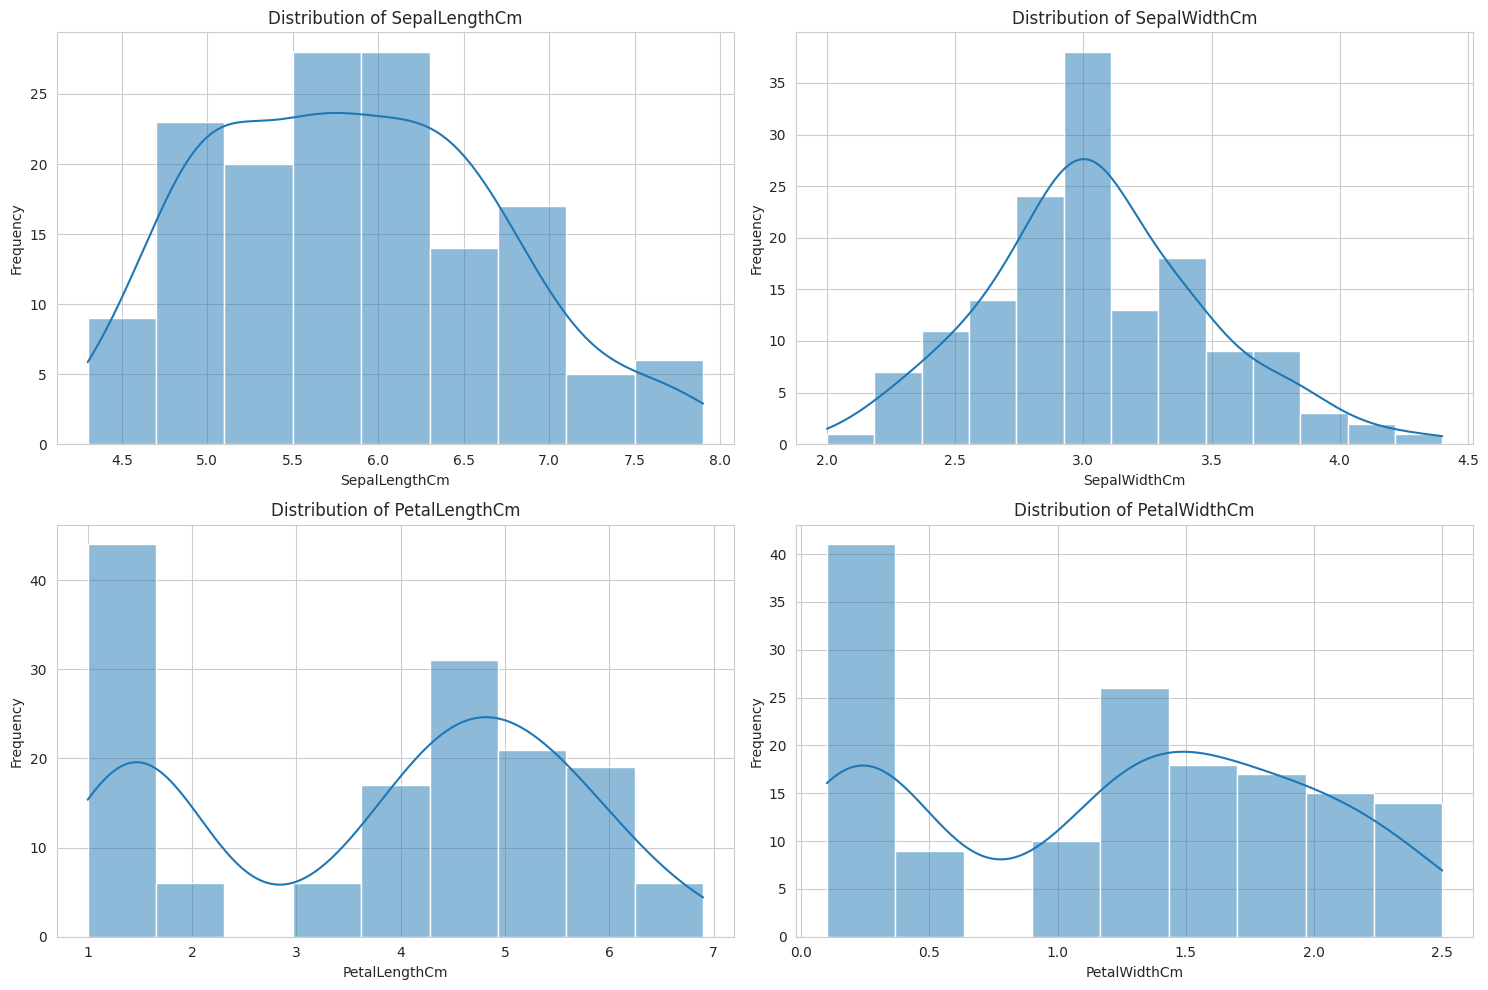

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Numerical features
numerical_cols = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1) # Create a 2x2 grid of subplots
    sns.histplot(df[col], kde=True) # Histogram with KDE for density
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

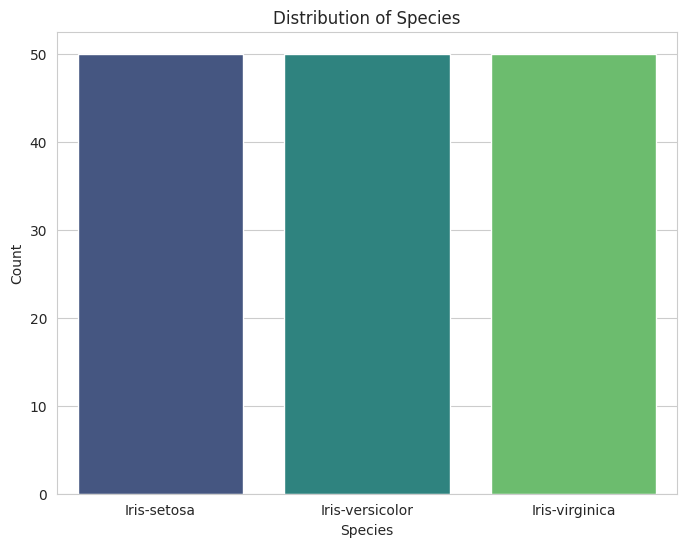

In [ ]:
# Categorical feature: Species
plt.figure(figsize=(8, 6))
sns.countplot(x='Species', data=df, palette='viridis', hue='Species', legend=False)
plt.title('Distribution of Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

**EXPLORATORY DATA ANALYSIS-UNIVARIATE**

For my Iris dataset assignment, I began with univariate analysis, focusing on each variable individually. I created histograms for the numerical features and a count plot for the categorical feature, Species.

Observations from the plots:
Numerical Features (Histograms):

SepalLengthCm: Displays an approximately normal distribution, slightly left‑skewed, with most values concentrated between 5 and 7 cm.

SepalWidthCm: Roughly normal but with two noticeable peaks around 3.0 cm and 3.5 cm, hinting at possible subgroupings in the data.

PetalLengthCm: Shows a bimodal or even trimodal pattern, with a clear divide between values below 2 cm and those above 3 cm. This separation is highly indicative of species differences.

PetalWidthCm: Similar to PetalLengthCm, it presents distinct peaks, making it another strong candidate for species classification.

Categorical Feature (Species Count Plot):

Each species (Iris‑setosa, Iris‑versicolor, Iris‑virginica) has exactly 50 samples, confirming that the dataset is balanced with respect to the target variable.





### Additional Univariate Analysis: Boxplots and Summary Statistics

In [ ]:
# Summary statistics for numerical features, grouped by Species
display(df.groupby('Species')[numerical_cols].describe())

SepalLengthCm                                              \
                        count   mean       std  min    25%  50%  75%  max   
Species                                                                     
Iris-setosa              50.0  5.006  0.352490  4.3  4.800  5.0  5.2  5.8   
Iris-versicolor          50.0  5.936  0.516171  4.9  5.600  5.9  6.3  7.0   
Iris-virginica           50.0  6.588  0.635880  4.9  6.225  6.5  6.9  7.9   

                SepalWidthCm         ... PetalLengthCm      PetalWidthCm  \
                       count   mean  ...           75%  max        count   
Species                              ...                                   
Iris-setosa             50.0  3.418  ...         1.575  1.9         50.0   
Iris-versicolor         50.0  2.770  ...         4.600  5.1         50.0   
Iris-virginica          50.0  2.974  ...         5.875  6.9         50.0   

                                                           
                  mean       std  min  25%  50%  75%  max  
Species                                                    
Iris-setosa      0.244  0.107210  0.1  0.2  0.2  0.3  0.6  
Iris-versicolor  1.326  0.197753  1.0  1.2  1.3  1.5  1.8  
Iris-virginica   2.026  0.274650  1.4  1.8  2.0  2.3  2.5  

[3 rows x 32 columns]

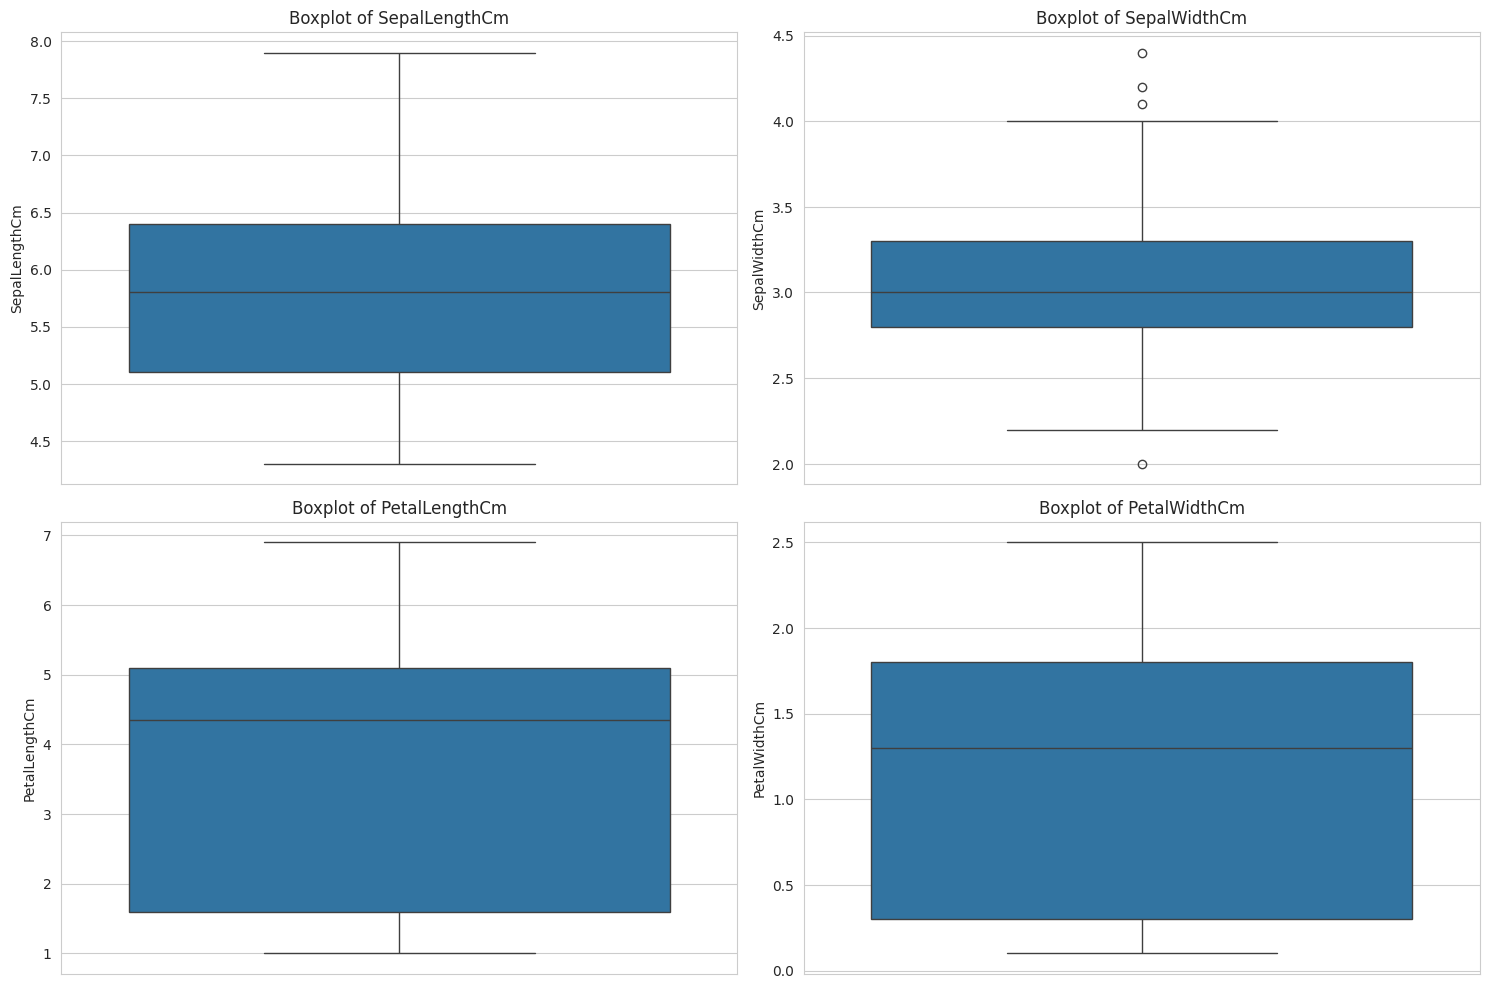

In [ ]:
# Boxplots for each numerical feature to visualize distribution and outliers across species
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=df[col]) # Removed palette as there is no hue
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

## Bivariate Analysis

Now, let's explore the relationships between different pairs of variables, particularly how numerical features relate to each other and to the 'Species' variable.

<Figure size 1000x800 with 0 Axes>

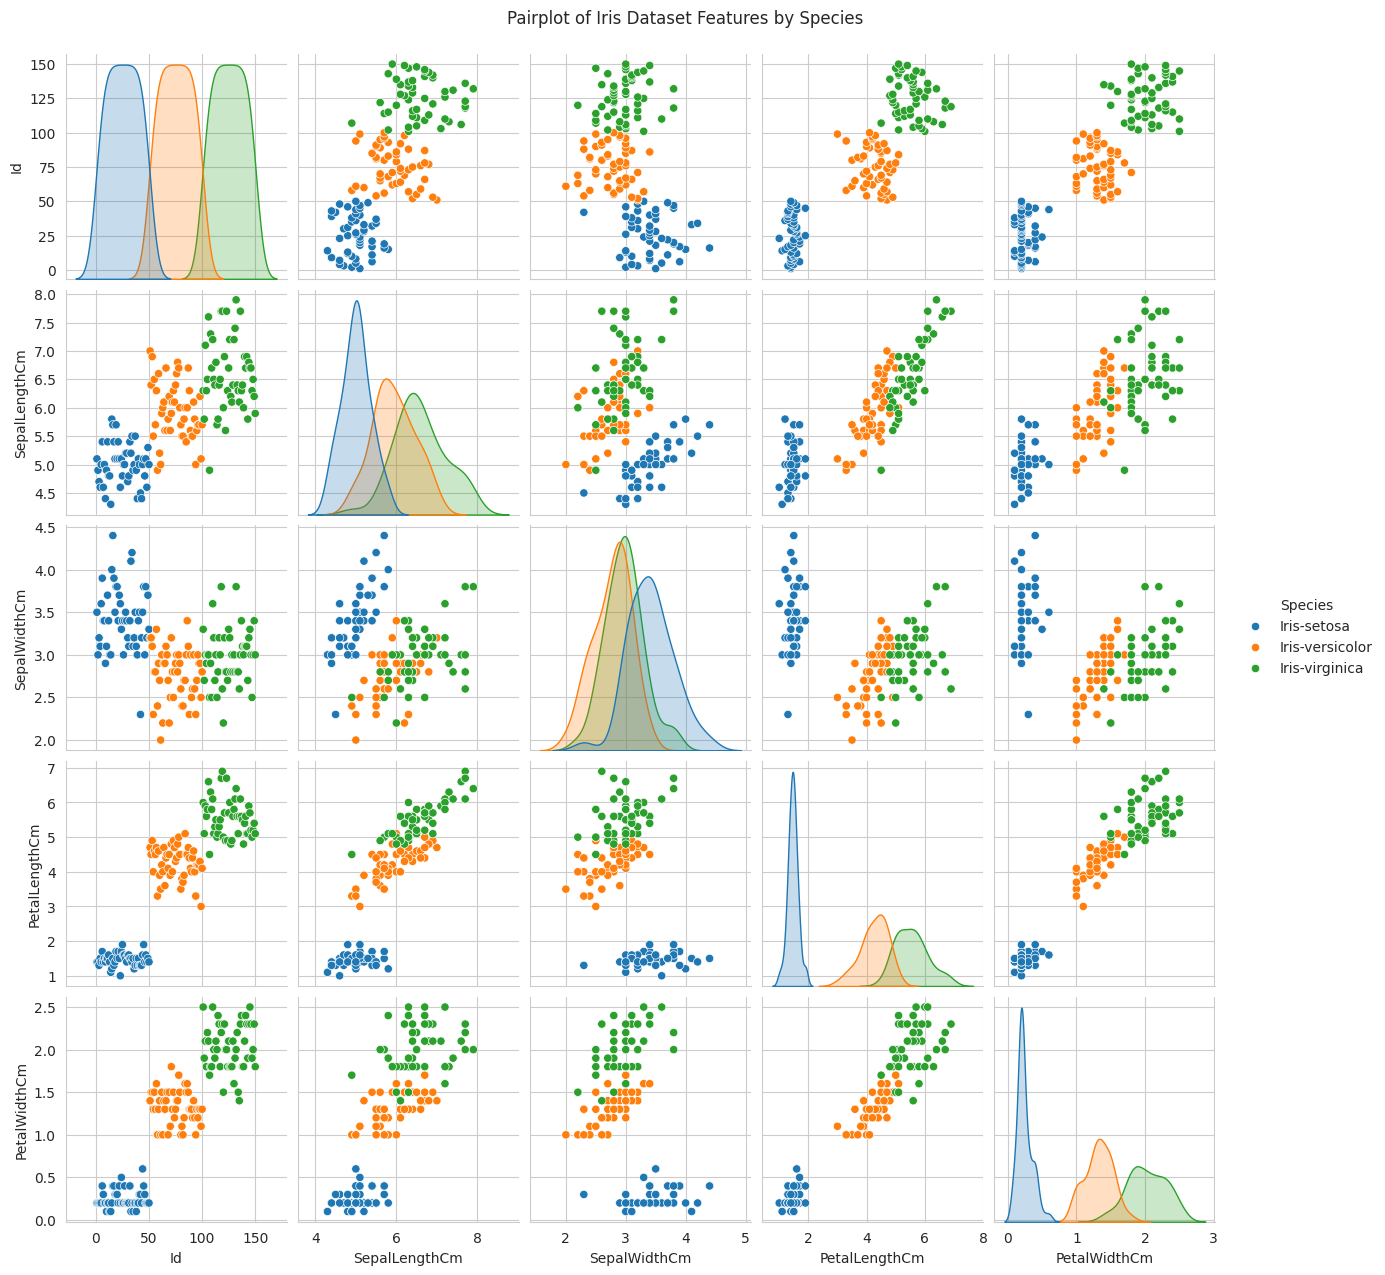

In [ ]:
# Pairplot to visualize relationships between numerical features, colored by Species
plt.figure(figsize=(10, 8))
sns.pairplot(df, hue='Species', diag_kind='kde')
plt.suptitle('Pairplot of Iris Dataset Features by Species', y=1.02) # Add a title above the plots
plt.show()

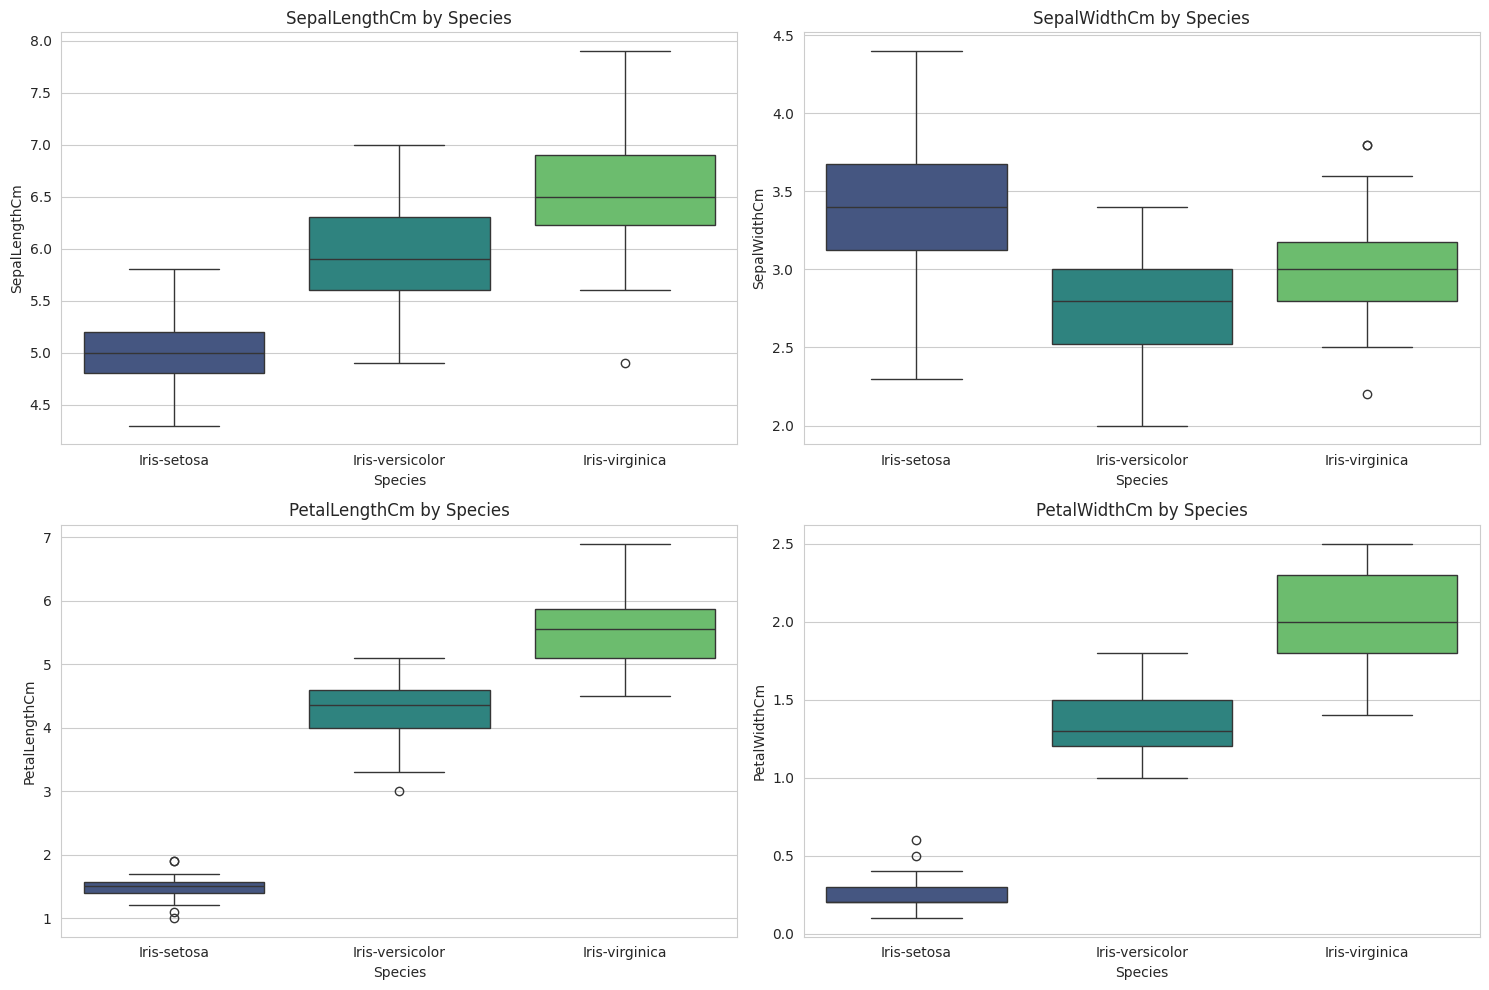

In [ ]:
# Boxplots for each numerical feature, grouped by Species
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x='Species', y=col, data=df, palette='viridis', hue='Species', legend=False) # Added hue and legend=False
    plt.title(f'{col} by Species')
    plt.xlabel('Species')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

### Correlation Matrix

Let's visualize the correlation between the numerical features using a heatmap.

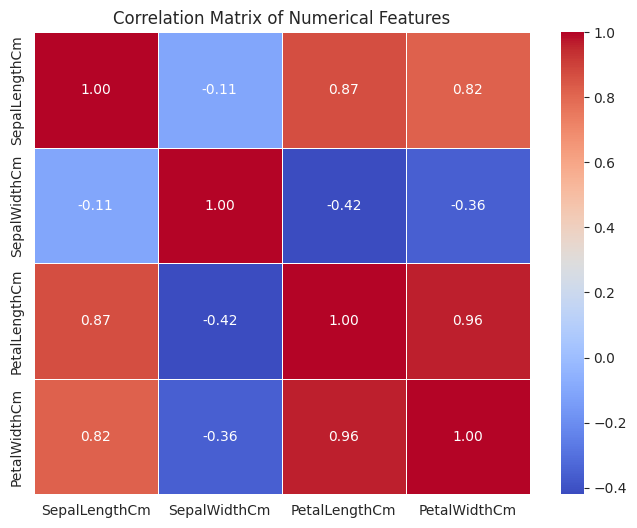

In [ ]:
# Calculate the correlation matrix for numerical columns
correlation_matrix = df[numerical_cols].corr()

# Plot the correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

**BIVARIATE**

Pairplot: A scatterplot matrix was generated to display interactions among all numerical features. Points were color‑coded by species, making it easy to observe clear separations between the three Iris classes.

Boxplots by Species: For each numerical feature (SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm), boxplots grouped by species were created. These highlight how the distribution of each feature varies across species, revealing distinct patterns useful for classification.

Correlation Matrix Heatmap: A heatmap of correlation coefficients was computed to show the strength and direction of relationships among numerical features. This visualization helps identify which features are most strongly related and may contribute to predictive modeling.

## CONCLUSION

The comprehensive Exploratory Data Analysis (EDA) of the Iris dataset has provided significant insights into its structure and the relationships between its features, with the primary objective of understanding how different measurements distinguish flower species.

### Summary of Key Findings:

**Univariate Analysis:**
*   **Balanced Dataset:** The `Species` count plot confirmed that the dataset is perfectly balanced, with 50 samples for each of the three Iris species (Iris-setosa, Iris-versicolor, Iris-virginica).
*   **Distinct Petal Distributions:** Histograms and boxplots revealed that `PetalLengthCm` and `PetalWidthCm` exhibit highly distinct, multi-modal distributions. This suggests that these features are strong indicators for differentiating between Iris species.
*   **Sepal Distributions:** `SepalLengthCm` showed a somewhat normal distribution with slight skewness, while `SepalWidthCm` displayed a bimodal tendency. While less discriminative than petal measurements, these still show variations across species.
*   **Species-Grouped Summary Statistics:** Detailed summary statistics, grouped by `Species`, reinforced these observations, quantitatively showing the mean, standard deviation, and range differences across species for each numerical feature.

**Bivariate Analysis:**
*   **Clear Species Separation (Pairplot & Grouped Boxplots):** The pairplot and boxplots grouped by `Species` clearly demonstrated that Iris-setosa is well-separated from Iris-versicolor and Iris-virginica, primarily based on `PetalLengthCm` and `PetalWidthCm`. Iris-versicolor and Iris-virginica show some overlap but are still largely distinguishable, especially with petal measurements.
*   **Strong Correlations:** The correlation matrix heatmap highlighted strong positive correlations between `PetalLengthCm` and `PetalWidthCm` (0.96), `SepalLengthCm` and `PetalLengthCm` (0.87), and `SepalLengthCm` and `PetalWidthCm` (0.82). This indicates that as one of these dimensions increases, the others tend to increase as well, especially within petals.

### Insights:
*   `PetalLengthCm` and `PetalWidthCm` are the most discriminative features for classifying Iris species. Their distinct distributions and clear separation across species in bivariate plots make them highly valuable for any predictive modeling task.
*   `SepalLengthCm` also contributes to species differentiation, though to a lesser extent than petal measurements.
*   `SepalWidthCm` shows the most overlap between species and has a slightly negative correlation with petal dimensions, suggesting it might be less critical for classification than other features.

### Next Steps:
Based on this comprehensive EDA, the logical next steps for this project would be:
1.  **Feature Engineering:** While the current features are quite strong, exploring ratios or combinations of existing features could potentially create even more powerful predictors.
2.  **Model Building:** Developing classification models (e.g., Logistic Regression, Support Vector Machines, Decision Trees, K-Nearest Neighbors) to predict the `Species` based on the observed numerical features.
3.  **Model Evaluation:** Rigorously evaluating the performance of these models using appropriate metrics (e.g., accuracy, precision, recall, F1-score) and cross-validation techniques.
4.  **Hyperparameter Tuning:** Optimizing the chosen model(s) to achieve the best possible predictive performance.